In [110]:
import torch

x = torch.tensor([1.0], requires_grad=True)
y = torch.nn.functional.relu(x)
grad = torch.autograd.grad(y.sum(), x, retain_graph=True, create_graph=True)[0] 
optimizer = torch.optim.Adam([x])
loss = (grad**2).sum()
optimizer.zero_grad()
loss.backward()
optimizer.step()
x.grad

tensor([0.])

In [ ]:
import lightning as L
from neural_poisson.model.mlp import MultiLayerPerceptron



L.seed_everything(1)


point = torch.tensor([[0.1, 0.0, 0.0]], requires_grad=True)
mlp = MultiLayerPerceptron(num_hidden_layers=0)
x, logit = mlp(point)
print(mlp)
x.grad_fn.next_functions[0]

Seed set to 1


MultiLayerPerceptron(
  (layer_in): Linear(in_features=3, out_features=256, bias=True)
  (activation_in): ReLUActivation()
  (layer_out): Linear(in_features=256, out_features=1, bias=False)
  (activation_out): SigmoidActivation()
)


((<MmBackward0 at 0x760077d7ae60>, 0),)

In [ ]:
(<MmBackward0 at 0x760077d0b670>, 0),)

In [ ]:
import torch
import lightning as L
import matplotlib.pyplot as plt
from torchviz import make_dot
from IPython.display import display
import lightning as L
import torch
from neural_poisson.model.mlp import MultiLayerPerceptron, SigmoidActivation, IdentityActivation, ReLUActivation, TanhActivation
L.seed_everything(1)


point = torch.tensor([[0.1, 0.1, 0.1]], requires_grad=True)
mlp = MultiLayerPerceptron(activation=ReLUActivation, out_activation=ReLUActivation, num_hidden_layers=0)
optimizer = torch.optim.Adam(mlp.parameters())
x, logit = mlp(point)
grad = torch.autograd.grad(x.sum(), point, retain_graph=True, create_graph=True)[0] 
# loss = torch.autograd.grad(grad.sum(), point, retain_graph=True, create_graph=True)[0] 
loss = (grad**2).sum()
loss = grad.sum()
# optimizer.zero_grad()
loss.backward()

print(mlp.layer_in.weight.grad[:10])
print(mlp.layer_in.weight[:10].mean(dim=-1))

# print(mlp.layer_out.weight.grad[:, :10])
# print(mlp.layer_out.weight[:, :10])
# print(mlp.layer_out.weight.grad.shape)
# print(point.grad)

# graph = make_dot(loss, params={"point": point, "grad": grad, "output": x, **dict(mlp.named_parameters())}, show_attrs=True, show_saved=True)
graph = make_dot(loss, params={"point": point, "grad": grad, "output": x, **dict(mlp.named_parameters())}, show_saved=True)
# graph = make_dot(loss, params={"point": point, "grad": grad, "output": x, **dict(mlp.named_parameters())})
display(graph)

Seed set to 1


TypeError: 'NoneType' object is not subscriptable

In [67]:
help(loss.grad_fn.next_functions[0][0].next_functions[0][0].next_functions[0][0])

Help on ThresholdBackwardBackward0 object:

class ThresholdBackwardBackward0(object)
 |  Methods defined here:
 |  
 |  __call__(self, /, *args, **kwargs)
 |      Call self as a function.
 |  
 |  name(...)
 |  
 |  register_hook(...)
 |  
 |  register_prehook(...)
 |  
 |  ----------------------------------------------------------------------
 |  Data descriptors defined here:
 |  
 |  metadata
 |  
 |  next_functions
 |  
 |  requires_grad



In [68]:
import torch
help(torch.nn.functional.threshold)  

Help on function _threshold in module torch.nn.functional:

_threshold(input: torch.Tensor, threshold: float, value: float, inplace: bool = False) -> torch.Tensor
    Apply a threshold to each element of the input Tensor.
    
    See :class:`~torch.nn.Threshold` for more details.



In [98]:
x = torch.randn(3, 3, requires_grad=True)
y = torch.threshold(x, 0, 1)
grad = torch.autograd.grad(y.sum(), x, retain_graph=True, create_graph=True)[0] 
loss = grad.sum()
loss.backward()
x.grad

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])

In [9]:
import torch
import lightning as L
from torch.utils.tensorboard import SummaryWriter
from neural_poisson.model.mlp import MultiLayerPerceptron, SigmoidActivation, TanhActivation

# Set seed for reproducibility
L.seed_everything(1)

# Initialize TensorBoard writer
writer = SummaryWriter("runs/mlp_graph")

# Define input point with requires_grad=True
point = torch.tensor([[0.1, 0.0, 0.0]], requires_grad=True)

# Initialize MLP
mlp = MultiLayerPerceptron(activation=TanhActivation, out_activation=SigmoidActivation, num_hidden_layers=0)
# mlp.activation_1 = SigmoidActivation()

# Forward pass
x, logit = mlp(point)

# Compute first-order gradient
grad = torch.autograd.grad(x.sum(), point, retain_graph=True, create_graph=True)[0] 

# Compute loss
loss = (grad**2).sum()

# Log computational graph
writer.add_graph(mlp, point)

# Perform backward pass
loss.backward()

# Close the writer
writer.close()

print("Graph logged to TensorBoard.")


Seed set to 1


Graph logged to TensorBoard.


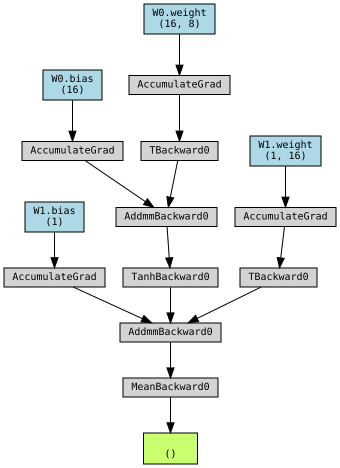

In [8]:
import torch.nn as nn
model = nn.Sequential()
model.add_module('W0', nn.Linear(8, 16))
model.add_module('tanh', nn.Tanh())
model.add_module('W1', nn.Linear(16, 1))

x = torch.randn(1, 8)
y = model(x)

make_dot(y.mean(), params=dict(model.named_parameters()))

In [164]:
grad_fn_printer(grad.grad_fn, 0, "")

 0 <MmBackward0 object at 0x760076d4e380> 2
0 1 <TanhBackwardBackward0 object at 0x760076d4e110> 2
0 2 <MmBackward0 object at 0x760076d4dcf0> 2
0 3 <SigmoidBackwardBackward0 object at 0x760076d4c130> 2
1 4 <SigmoidBackward0 object at 0x760076d4d510> 1
0 5 <MmBackward0 object at 0x760076d4c370> 2
0 6 <TanhBackward0 object at 0x760076d4f2b0> 1
0 7 <AddmmBackward0 object at 0x760076d4f670> 3
0 8 <AccumulateGrad object at 0x760076d4f910> 0
1 8 <AccumulateGrad object at 0x760076d4c850> 0
2 8 <TBackward0 object at 0x760076d4f4f0> 1
0 9 <AccumulateGrad object at 0x760076d4c670> 0
1 6 <TBackward0 object at 0x760076d4d720> 1
0 7 <AccumulateGrad object at 0x760076d4f670> 0
1 3 <TBackward0 object at 0x760076d4c0a0> 1
0 4 <TBackward0 object at 0x760076d4d510> 1
0 5 <AccumulateGrad object at 0x760076d4c370> 0
1 2 <TanhBackward0 object at 0x760076d4f2b0> 1
0 3 <AddmmBackward0 object at 0x760076d4c0a0> 3
0 4 <AccumulateGrad object at 0x760076d4c130> 0
1 4 <AccumulateGrad object at 0x760076d4d510> 0
2

In [ ]:
#  0 <MmBackward0 object at 0x760076d4e380> 2
# 0 1 <TanhBackwardBackward0 object at 0x760076d4e110> 2
# 0 2 <MmBackward0 object at 0x760076d4dcf0> 2
# 0 3 <SigmoidBackwardBackward0 object at 0x760076d4c130> 2
    # 1 4 <SigmoidBackward0 object at 0x760076d4d510> 1
    # 0 5 <MmBackward0 object at 0x760076d4c370> 2
    # 0 6 <TanhBackward0 object at 0x760076d4f2b0> 1
    # 0 7 <AddmmBackward0 object at 0x760076d4f670> 3
    # 0 8 <AccumulateGrad object at 0x760076d4f910> 0
    # 1 8 <AccumulateGrad object at 0x760076d4c850> 0
    # 2 8 <TBackward0 object at 0x760076d4f4f0> 1
    # 0 9 <AccumulateGrad object at 0x760076d4c670> 0
    # 1 6 <TBackward0 object at 0x760076d4d720> 1
    # 0 7 <AccumulateGrad object at 0x760076d4f670> 0
# 1 3 <TBackward0 object at 0x760076d4c0a0> 1
# 0 4 <TBackward0 object at 0x760076d4d510> 1
# 0 5 <AccumulateGrad object at 0x760076d4c370> 0
# 1 2 <TanhBackward0 object at 0x760076d4f2b0> 1
# 0 3 <AddmmBackward0 object at 0x760076d4c0a0> 3
# 0 4 <AccumulateGrad object at 0x760076d4c130> 0
# 1 4 <AccumulateGrad object at 0x760076d4d510> 0
# 2 4 <TBackward0 object at 0x760076d4ea40> 1
# 0 5 <AccumulateGrad object at 0x760076d4d000> 0
# 1 1 <TBackward0 object at 0x760076d4f790> 1
# 0 2 <TBackward0 object at 0x760076d4f2b0> 1
# 0 3 <AccumulateGrad object at 0x760076d4dcf0> 0